# Value Iteration

[[0.006 0.009 0.012 0.018 0.025 0.032 0.04  0.043]
 [0.006 0.008 0.011 0.016 0.026 0.036 0.049 0.057]
 [0.005 0.006 0.007 0.    0.026 0.039 0.068 0.084]
 [0.004 0.005 0.006 0.008 0.02  0.    0.092 0.129]
 [0.003 0.003 0.003 0.    0.034 0.062 0.109 0.21 ]
 [0.002 0.    0.    0.011 0.033 0.063 0.    0.36 ]
 [0.001 0.    0.001 0.004 0.    0.116 0.    0.631]
 [0.001 0.001 0.001 0.    0.138 0.323 0.614 0.   ]]


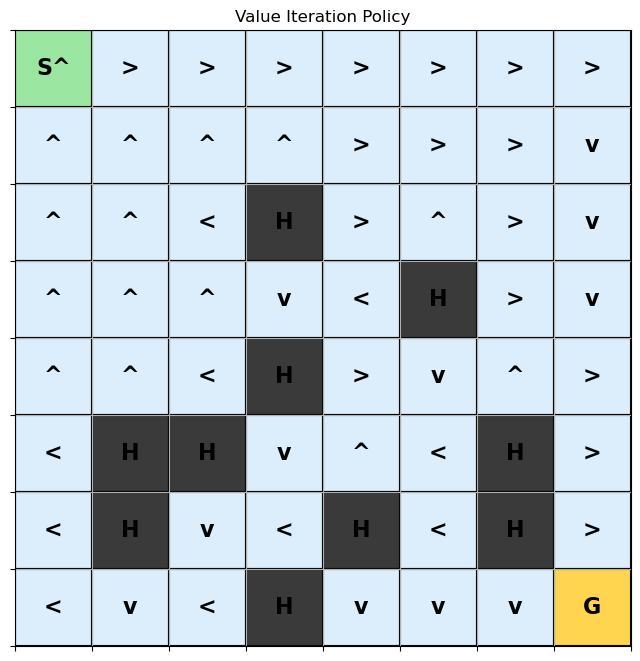

In [4]:
import gymnasium as gym
from matplotlib import pyplot as plt
import numpy as np

env = gym.make("FrozenLake-v1",map_name='8x8',is_slippery = True)
p = env.unwrapped.P
states = env.observation_space.n
actions = env.action_space.n
gamma = 0.9
theta = 1e-6
v = np.zeros(states)

while True:
    delta = 0
    for s in range(states):
        intial_value = v[s]
        q_value = []
        for a in range(actions):
            q = 0
            for prob,new_state,reward,done in p[s][a]:
                q+=prob*(reward+gamma*v[new_state])
            q_value.append(q)
        v[s] = max(q_value)
        delta = max(delta,abs(intial_value-v[s]))                 
    if delta < theta:
        break
print(np.round(v.reshape(8,8),3))

policy = np.zeros(states,dtype =int)
for s in range(states):
        q_value = []
        for a in range(actions):
            q = 0
            for prob,new_state,reward,done in p[s][a]:
                q+=prob*(reward+gamma*v[new_state])
            q_value.append(q)
        policy[s] = np.argmax(q_value)

def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
    desc = np.asarray(env.unwrapped.desc, dtype=str)
    policy_grid = np.asarray(policy).reshape(desc.shape)

    arrows = np.array(["<", "v", ">", "^"])

    colors = {
        "S": "#9be7a1",
        "F": "#dceefb",
        "H": "#3a3a3a",
        "G": "#ffd54f",
    }

    fig, ax = plt.subplots(figsize=(8, 8))

    for r in range(desc.shape[0]):
        for c in range(desc.shape[1]):

            tile = desc[r, c]

            rect = plt.Rectangle(
                (c, desc.shape[0] - 1 - r),
                1,
                1,
                facecolor=colors[tile],
                edgecolor="black",
                linewidth=1.5,
            )

            ax.add_patch(rect)

            if tile == "H":
                label = "H"

            elif tile == "G":
                label = "G"

            elif tile == "S":
                label = f"S{arrows[policy_grid[r,c]]}"

            else:
                label = arrows[policy_grid[r,c]]

            ax.text(
                c + 0.5,
                desc.shape[0] - 1 - r + 0.5,
                label,
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold",
                color="black",
            )

    ax.set_xlim(0, desc.shape[1])
    ax.set_ylim(0, desc.shape[0])

    ax.set_xticks(np.arange(desc.shape[1] + 1))
    ax.set_yticks(np.arange(desc.shape[0] + 1))

    ax.grid(True)

    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.set_aspect("equal")

    plt.title(title)
    plt.show()

plot_policy_on_frozen_lake(env,policy,title="Value Iteration Policy")




# Policy Iteration

[[0.006 0.008 0.012 0.018 0.025 0.032 0.039 0.043]
 [0.005 0.007 0.011 0.016 0.026 0.036 0.049 0.057]
 [0.004 0.005 0.006 0.    0.025 0.039 0.068 0.084]
 [0.004 0.004 0.005 0.008 0.02  0.    0.092 0.129]
 [0.003 0.003 0.002 0.    0.034 0.062 0.109 0.21 ]
 [0.001 0.    0.    0.011 0.032 0.063 0.    0.36 ]
 [0.001 0.    0.001 0.004 0.    0.116 0.    0.631]
 [0.    0.001 0.001 0.    0.138 0.323 0.614 0.   ]]


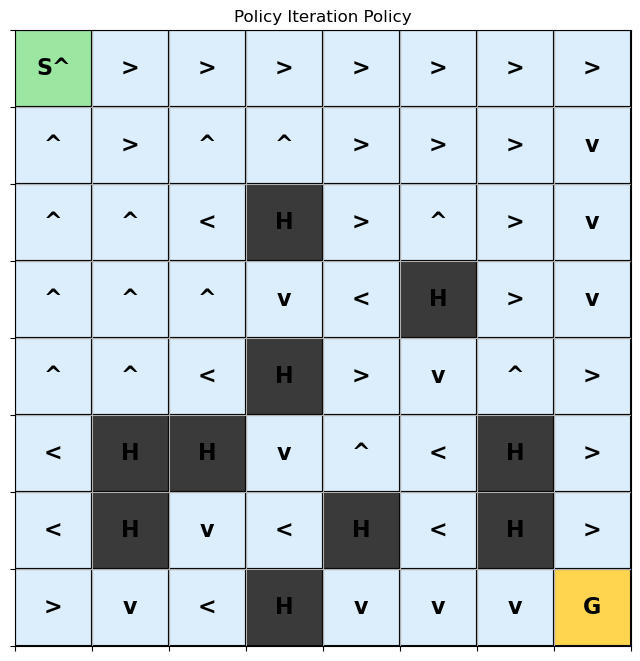

In [5]:
import gymnasium as gym
from matplotlib import pyplot as plt
import numpy as np

env = gym.make("FrozenLake-v1",map_name='8x8')
p = env.unwrapped.P
states = env.observation_space.n
actions = env.action_space.n
gamma = 0.9
theta = 1e-3

policy = np.zeros(states,dtype=int)
v = np.zeros(states)

while True:
    while True:
        delta = 0
        for s in range(states):
            intial_value = v[s]
            a = policy[s]
            value = 0
            for prob,new_state,reward,done in p[s][a]:
                value += prob * (reward + gamma * v[new_state])
            v[s] = value
            delta = max(delta,abs(intial_value-v[s]))
        if delta < theta:
            break

    stable = True
    for s in range(states):
        old_action = policy[s]
        q_value = []
        for a in range(actions):
            q = 0
            for prob,new_state,reward,done in p[s][a]:
                q += prob * (reward + gamma * v[new_state])
            q_value.append(q)
        policy[s] = np.argmax(q_value)
        if old_action != policy[s]:
            stable = False
    if stable:
        break

def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
    desc = np.asarray(env.unwrapped.desc, dtype=str)
    policy_grid = np.asarray(policy).reshape(desc.shape)

    arrows = np.array(["<", "v", ">", "^"])

    colors = {
        "S": "#9be7a1",
        "F": "#dceefb",
        "H": "#3a3a3a",
        "G": "#ffd54f",
    }

    fig, ax = plt.subplots(figsize=(8, 8))

    for r in range(desc.shape[0]):
        for c in range(desc.shape[1]):

            tile = desc[r, c]

            rect = plt.Rectangle(
                (c, desc.shape[0] - 1 - r),
                1,
                1,
                facecolor=colors[tile],
                edgecolor="black",
                linewidth=1.5,
            )

            ax.add_patch(rect)

            if tile == "H":
                label = "H"

            elif tile == "G":
                label = "G"

            elif tile == "S":
                label = f"S{arrows[policy_grid[r,c]]}"

            else:
                label = arrows[policy_grid[r,c]]

            ax.text(
                c + 0.5,
                desc.shape[0] - 1 - r + 0.5,
                label,
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold",
                color="black",
            )

    ax.set_xlim(0, desc.shape[1])
    ax.set_ylim(0, desc.shape[0])

    ax.set_xticks(np.arange(desc.shape[1] + 1))
    ax.set_yticks(np.arange(desc.shape[0] + 1))

    ax.grid(True)

    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.set_aspect("equal")

    plt.title(title)
    plt.show()
    
print(np.round(v.reshape(8,8),3))
plot_policy_on_frozen_lake(env,policy,title="Policy Iteration Policy")

# Matrix Method

[[ 0.006  0.009  0.012  0.018  0.025  0.032  0.04   0.043]
 [ 0.006  0.008  0.011  0.016  0.026  0.036  0.049  0.057]
 [ 0.005  0.006  0.007  0.     0.026  0.039  0.068  0.084]
 [ 0.004  0.005  0.006  0.008  0.02   0.     0.092  0.129]
 [ 0.003  0.003  0.003  0.     0.034  0.062  0.109  0.21 ]
 [ 0.002  0.    -0.     0.011  0.033  0.063  0.     0.36 ]
 [ 0.001 -0.     0.001  0.004  0.     0.116  0.     0.631]
 [ 0.001  0.001  0.001 -0.     0.138  0.323  0.614  0.   ]]


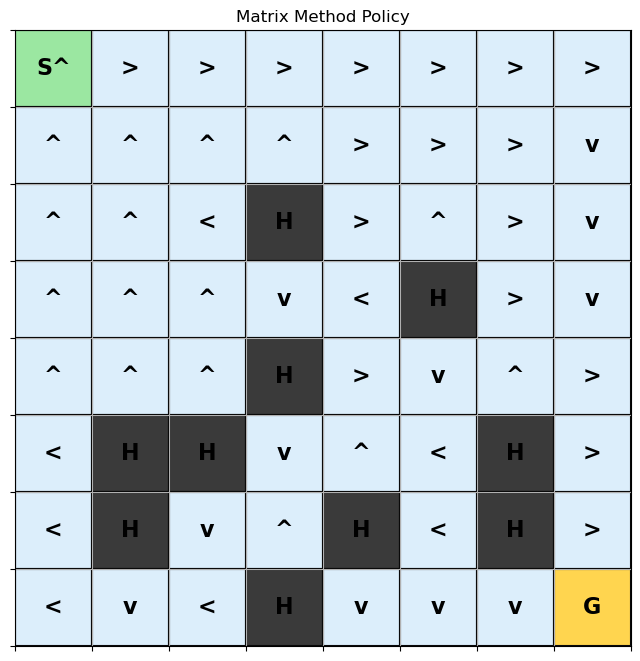

In [6]:
import gymnasium as gym
from matplotlib import pyplot as plt
import numpy as np

env = gym.make("FrozenLake-v1", map_name="8x8")
p = env.unwrapped.P
states = env.observation_space.n
actions = env.action_space.n
gamma = 0.9

policy = np.zeros(states, dtype=int)

while True:

    P_pi = np.zeros((states, states))
    R_pi = np.zeros(states)
    
    for s in range(states):
        a = policy[s]
        for prob, new_state, reward, done in p[s][a]:
            P_pi[s][new_state] += prob
            R_pi[s] += prob * reward
    v = np.linalg.solve(np.eye(states) - gamma * P_pi,R_pi)
    stable = True

    for s in range(states):
        old_action = policy[s]
        q_value = []
        for a in range(actions):
            q = 0
            for prob, new_state, reward, done in p[s][a]:
                q += prob * (reward +gamma * v[new_state])
            q_value.append(q)
        policy[s] = np.argmax(q_value)
        if old_action != policy[s]:
            stable = False

    if stable:
        break

def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
    desc = np.asarray(env.unwrapped.desc, dtype=str)
    policy_grid = np.asarray(policy).reshape(desc.shape)

    arrows = np.array(["<", "v", ">", "^"])

    colors = {
        "S": "#9be7a1",
        "F": "#dceefb",
        "H": "#3a3a3a",
        "G": "#ffd54f",
    }

    fig, ax = plt.subplots(figsize=(8, 8))

    for r in range(desc.shape[0]):
        for c in range(desc.shape[1]):

            tile = desc[r, c]

            rect = plt.Rectangle(
                (c, desc.shape[0] - 1 - r),
                1,
                1,
                facecolor=colors[tile],
                edgecolor="black",
                linewidth=1.5,
            )

            ax.add_patch(rect)

            if tile == "H":
                label = "H"

            elif tile == "G":
                label = "G"

            elif tile == "S":
                label = f"S{arrows[policy_grid[r,c]]}"

            else:
                label = arrows[policy_grid[r,c]]

            ax.text(
                c + 0.5,
                desc.shape[0] - 1 - r + 0.5,
                label,
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold",
                color="black",
            )

    ax.set_xlim(0, desc.shape[1])
    ax.set_ylim(0, desc.shape[0])

    ax.set_xticks(np.arange(desc.shape[1] + 1))
    ax.set_yticks(np.arange(desc.shape[0] + 1))

    ax.grid(True)

    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.set_aspect("equal")

    plt.title(title)
    plt.show()
    
print(np.round(v.reshape(8,8),3))
plot_policy_on_frozen_lake(env,policy,title="Matrix Method Policy")